In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
data_sample = pd.read_csv('../data/raw/0_c2264c30c100.csv', skiprows=20)
data_sample.info()
data_sample.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   TIME    100000 non-null  float64
 1   CH1     100000 non-null  float64
 2   CH2     100000 non-null  float64
 3   CH3     100000 non-null  float64
 4   CH4     100000 non-null  float64
dtypes: float64(5)
memory usage: 3.8 MB


,TIME,CH1,CH2,CH3,CH4
0,-5.0000,1.584,0.68,0.80,1.54
1,-4.9999,1.584,0.68,0.82,1.54
2,-4.9998,1.584,0.68,0.84,1.52
3,-4.9997,1.568,0.66,0.84,1.50
4,-4.9996,1.568,0.68,0.86,1.50


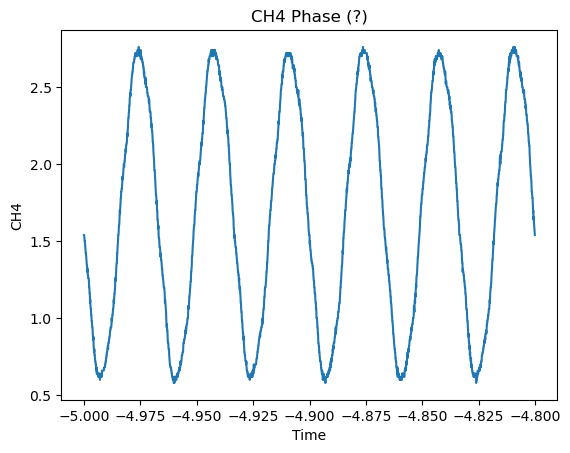

In [22]:
plt.plot(data_sample['TIME'][:2000], data_sample['CH4'][:2000])
plt.xlabel('Time')
plt.ylabel('CH4')
plt.title('CH4 Phase (?)')
plt.show()

In [46]:
def calc_mean(series: pd.Series):
    return np.mean(series)

def calc_RMS(series: pd.Series | np.ndarray):
    return np.sqrt(np.mean(series * series))

def calc_std(series: pd.Series):
    return np.std(series)

def calc_peak2peak(series: pd.Series | np.ndarray):
    return (np.max(series) - np.min(series))

In [25]:
print(calc_mean(data_sample['CH1']))
print(calc_RMS(data_sample['CH1']))
print(calc_std(data_sample['CH1']))
print(calc_peak2peak(data_sample['CH1']))

1.6248976000000002
1.6287579526989269
0.1120725568292451
0.712


In [41]:
def calc_skewness(series: pd.Series | np.ndarray):
    mean = np.mean(series)
    std = np.std(series)
    z = (series - mean) ** 3
    z_mean = np.mean(z)
    return z_mean / (std ** 3)

def calc_kurtosis(series: pd.Series | np.ndarray):
    mean = np.mean(series)
    std = np.std(series)
    z = (series - mean) ** 4
    z_mean = np.mean(z)
    return z_mean / (std ** 4)

In [45]:
print(calc_skewness(data_sample['CH4']))
print(calc_kurtosis(data_sample['CH3']))

-0.012005510706333163
1.5054948051436763


In [52]:
def calc_CrestFactor(series: pd.Series | np.ndarray):
    abs_max = np.max(np.abs(series))
    RMS = calc_RMS(series)
    return abs_max / RMS

def calc_FormFactor(series: pd.Series | np.ndarray):
    RMS = calc_RMS(series)
    abs_mean = np.mean(np.abs(series))
    return RMS / abs_mean

def calc_ClearenceFactor(series: pd.Series | np.ndarray):
    abs_max = np.max(np.abs(series))
    abs_sqrt_mean = np.mean(np.sqrt(np.abs(series)))
    return abs_max / (abs_sqrt_mean ** 2) 

def calc_ZeroCrossingRate(series: pd.Series | np.ndarray, threshold= 1e-6):
    signs = np.zeros_like(series)
    signs[series < threshold] = -1
    signs[series > threshold] = 1
    
    diff = np.diff(signs)
    
    return np.count_nonzero(diff) / len(series)

In [55]:
print(calc_CrestFactor(data_sample['CH1']))
print(calc_FormFactor(data_sample['CH1']))
print(calc_ClearenceFactor(data_sample['CH1']))
print(calc_ZeroCrossingRate(data_sample['CH1']))

1.2082826651676104
1.0023757513697642
1.212602601565051
0.0


Let's get the sampling rate for the Fourier Transform

In [56]:
t1 = data_sample['TIME'][1]
t2 = data_sample['TIME'][2]
delta_t = t2 - t1
print(delta_t)
print(1/ delta_t)

0.00010000000000065512
9999.999999934487


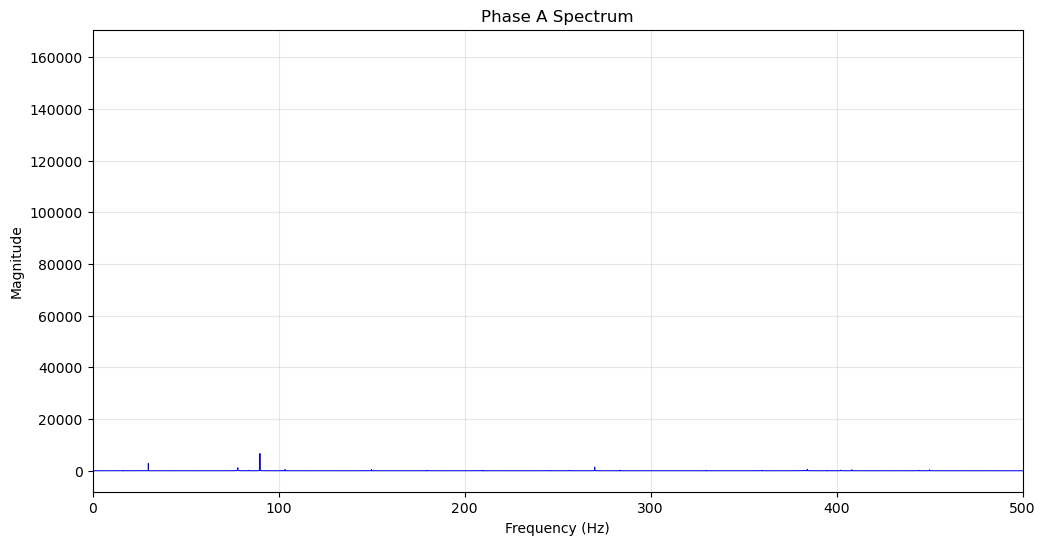

In [68]:
def plot_motor_spectrum(signal, fs, title="Frequency Spectrum"):
    # 1. Perform the Real FFT
    n = len(signal)
    magnitudes = np.abs(np.fft.rfft(signal))
    frequencies = np.fft.rfftfreq(n, d=1/fs)

    # 2. Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(frequencies, magnitudes, color='blue', lw=0.7)
    
    # 3. Focus on the important part
    # Since driving frequency is 30-60Hz, let's look at 0-500Hz 
    # to see the fundamental and the first 10 harmonics.
    plt.xlim(0, 500) 
    
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.3)
    plt.show()

# Usage:
plot_motor_spectrum(data_sample['CH1'], 10000, "Phase A Spectrum")

In [ ]:
def get_fft_data(series, sampling_rate):
    n = len(series)
    # Perform the FFT
    fft_values = np.fft.rfft(series)
    # Get the magnitudes (amplitudes)
    magnitudes = np.abs(fft_values)
    # Get the frequency axis
    frequencies = np.fft.rfftfreq(n, d=1/sampling_rate)
    return frequencies, magnitudes

In [69]:
def get_fft_data(series, sampling_rate):
    n = len(series)
    
    fft_values = np.fft.rfft(series)
    
    magnitudes = np.abs(fft_values)
    
    frequencies = np.fft.rfftfreq(n=n, d = 1/sampling_rate)
    return frequencies, magnitudes

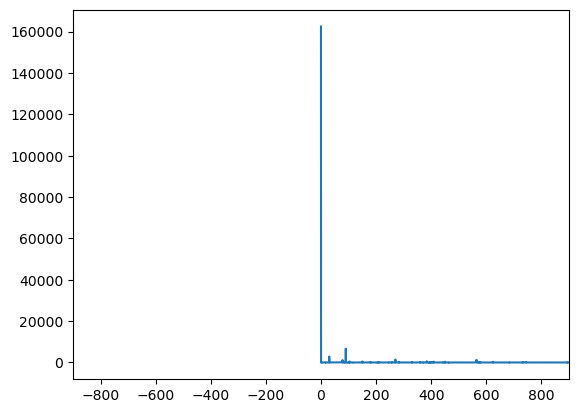

In [80]:
x, freq = get_fft_data(data_sample['CH1'], 10000)
plt.xlim(-900, 900)
plt.plot(x, freq)

In [ ]:
def calc_FundamentalFrequency(frequencies, magnitudes):
    index_max = np.argmax(magnitudes)
    return frequencies[index_max]

def get_HarmonicMagnitudes(frequencies, magnitudes, fund_freq, n_harmonics = 7):
    harmonic_magnitudes = np.zeros(8)
    for i in range(0, n_harmonics):
        harmonic_magnitudes = magnitudes[]

In [84]:
# np.argmax([1,2,33,4])
np.zeros(3)

array([0., 0., 0.])